In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import random
import time
import seaborn as sns

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# load
d = np.load("processed_waveforms.npz")
 # ["X_euclidean"] or ["X_voltage"] 
X = d["X_voltage"].astype(np.float32)  
# 0=photon, 1=neutron
y = d["y"].astype(np.int32)             

# split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#Normalize to [0, 1]
minv = X_train.min(axis=0, keepdims=True)    
maxv = X_train.max(axis=0, keepdims=True)   
den  = np.maximum(maxv - minv, 1e-8)

X_train_n = (X_train - minv) / den
X_test_n  = (X_test  - minv) / den

In [14]:
input_length = np.shape(X_train_n)[1]
latent_dim = 8
inputs = tf.keras.Input(shape=(input_length, 1))

#  Encoder 
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)   
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)  
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   
shape = x.shape[1:]  

# Feature vector 
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x) #Flatten into latent dimension

#  Decoder (input is feature vector) 
x = layers.Dense(shape[0] * shape_before_flatten[1], activation='relu')(latent)
x = layers.Reshape(shape)(x)
x = layers.UpSampling1D(2)(x)  
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)  
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)  
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

#Reconstructed Signal 
reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(1, activation='sigmoid', name="classification")(clf)

# Full Model 
model = Model(inputs, [reconstruction, classification])

In [15]:
model.compile(
    optimizer='adam',
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy'},
    loss_weights={
        'reconstruction': 1.0,
        'classification': 1.0},
    metrics={
        'classification': ['accuracy']})

In [7]:
history = model.fit(
    X_train,
    {
        "reconstruction": X_train_n,
        "classification": Y_train},
    validation_data=(
        X_test,
        {
            "reconstruction": X_test_n,
            "classification": Y_test}
    ),
    epochs=50,
    batch_size=512
)

Epoch 1/50


2026-04-10 12:36:56.704105: I external/local_xla/xla/service/service.cc:163] XLA service 0x1462900027c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-10 12:36:56.704124: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla V100-PCIE-16GB, Compute Capability 7.0
2026-04-10 12:36:56.810718: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 12:36:57.379896: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


 15/813 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - classification_accuracy: 0.5562 - classification_loss: 0.6908 - loss: 0.7206 - reconstruction_loss: 0.0298

I0000 00:00:1775839021.095291 3403983 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


813/813 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - classification_accuracy: 0.9641 - classification_loss: 0.0828 - loss: 0.0848 - reconstruction_loss: 0.0020 - val_classification_accuracy: 0.9905 - val_classification_loss: 0.0260 - val_loss: 0.0268 - val_reconstruction_loss: 9.2232e-04
Epoch 2/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - classification_accuracy: 0.9882 - classification_loss: 0.0301 - loss: 0.0310 - reconstruction_loss: 9.1486e-04 - val_classification_accuracy: 0.9914 - val_classification_loss: 0.0225 - val_loss: 0.0232 - val_reconstruction_loss: 8.6716e-04
Epoch 3/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - classification_accuracy: 0.9896 - classification_loss: 0.0266 - loss: 0.0275 - reconstruction_loss: 8.4883e-04 - val_classification_accuracy: 0.9916 - val_classification_loss: 0.0241 - val_loss: 0.0249 - val_reconstruction_loss: 8.1800e-04
Epoch 4/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - classification_accuracy: 0.9913 - classification_loss: 0.0224 - loss: 0

3251/3251 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


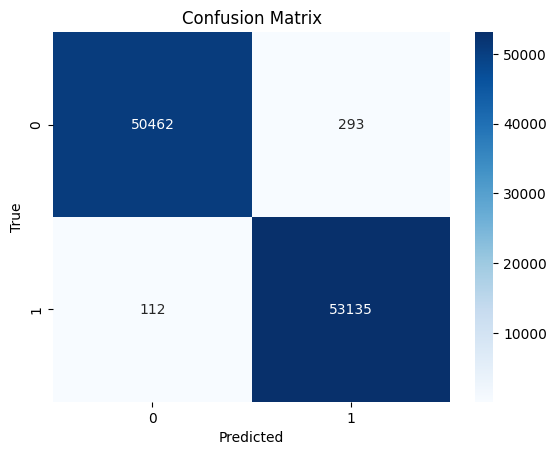

In [8]:
# Get predictions
y_pred = model.predict(X_test)[1]

# Convert probabilities to binary
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label
cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

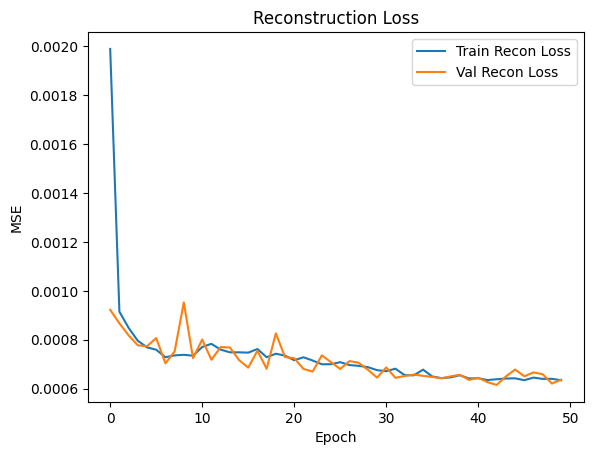

In [9]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

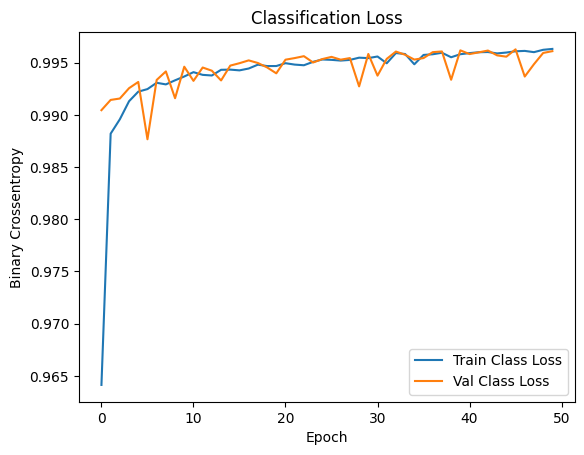

In [10]:
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Train Class Loss')
plt.plot(history.history['val_classification_accuracy'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()